In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [3]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

In [4]:
import numpy as np

cat_label = 3
dog_label = 5

train_filter = np.where((train_labels == cat_label) | (train_labels == dog_label))[0]
test_filter = np.where((test_labels == cat_label) | (test_labels == dog_label))[0]

train_images = train_images[train_filter]
train_labels = train_labels[train_filter]

test_images = test_images[test_filter]
test_labels = test_labels[test_filter]

In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

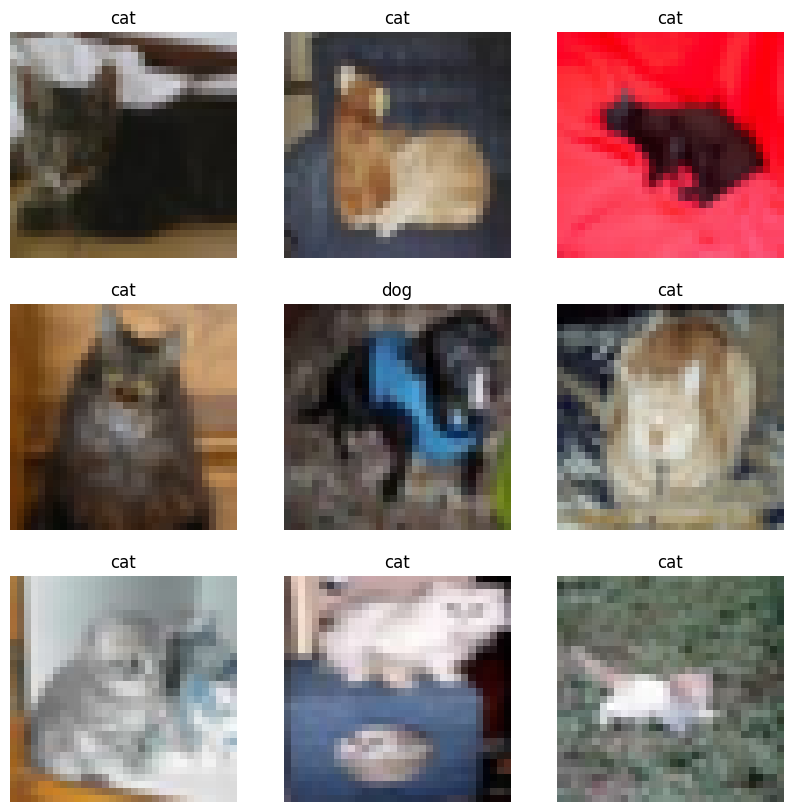

In [6]:
class_names = ['cat', 'dog']

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i])

    label = "cat" if train_labels[i] == 3 else "dog"

    plt.title(label)
    plt.axis("off")

plt.show()

In [7]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(1, activation='sigmoid'))

d:\Documents\Code\Projects\image-classifier\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_images,
    train_labels == dog_label,
    epochs=5,
    validation_data=(test_images, test_labels == dog_label)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5734 - loss: 0.6725 - val_accuracy: 0.6090 - val_loss: 0.6439
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6545 - loss: 0.6188 - val_accuracy: 0.6625 - val_loss: 0.6072
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7098 - loss: 0.5649 - val_accuracy: 0.7025 - val_loss: 0.5614
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7262 - loss: 0.5372 - val_accuracy: 0.7340 - val_loss: 0.5249
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7506 - loss: 0.5040 - val_accuracy: 0.7370 - val_loss: 0.5243


In [10]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels == dog_label
)

print("Accuracy:", test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7370 - loss: 0.5243
Accuracy: 0.7369999885559082


In [11]:
model.save("cats_vs_dogs_model.h5")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "test_images/test.jpg",
    target_size=(32,32)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print(prediction)

if prediction[0][0] > 0.5:
    print("DOG 🐶")
else:
    print("CAT 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[[0.92410135]]
DOG 🐶
